## Assignment 1: Data Analysis and Machine Learning

### Ky Cuong Pham a1906313

#### How can we use data analytics and Machine Learning to predict energy usage for this house?

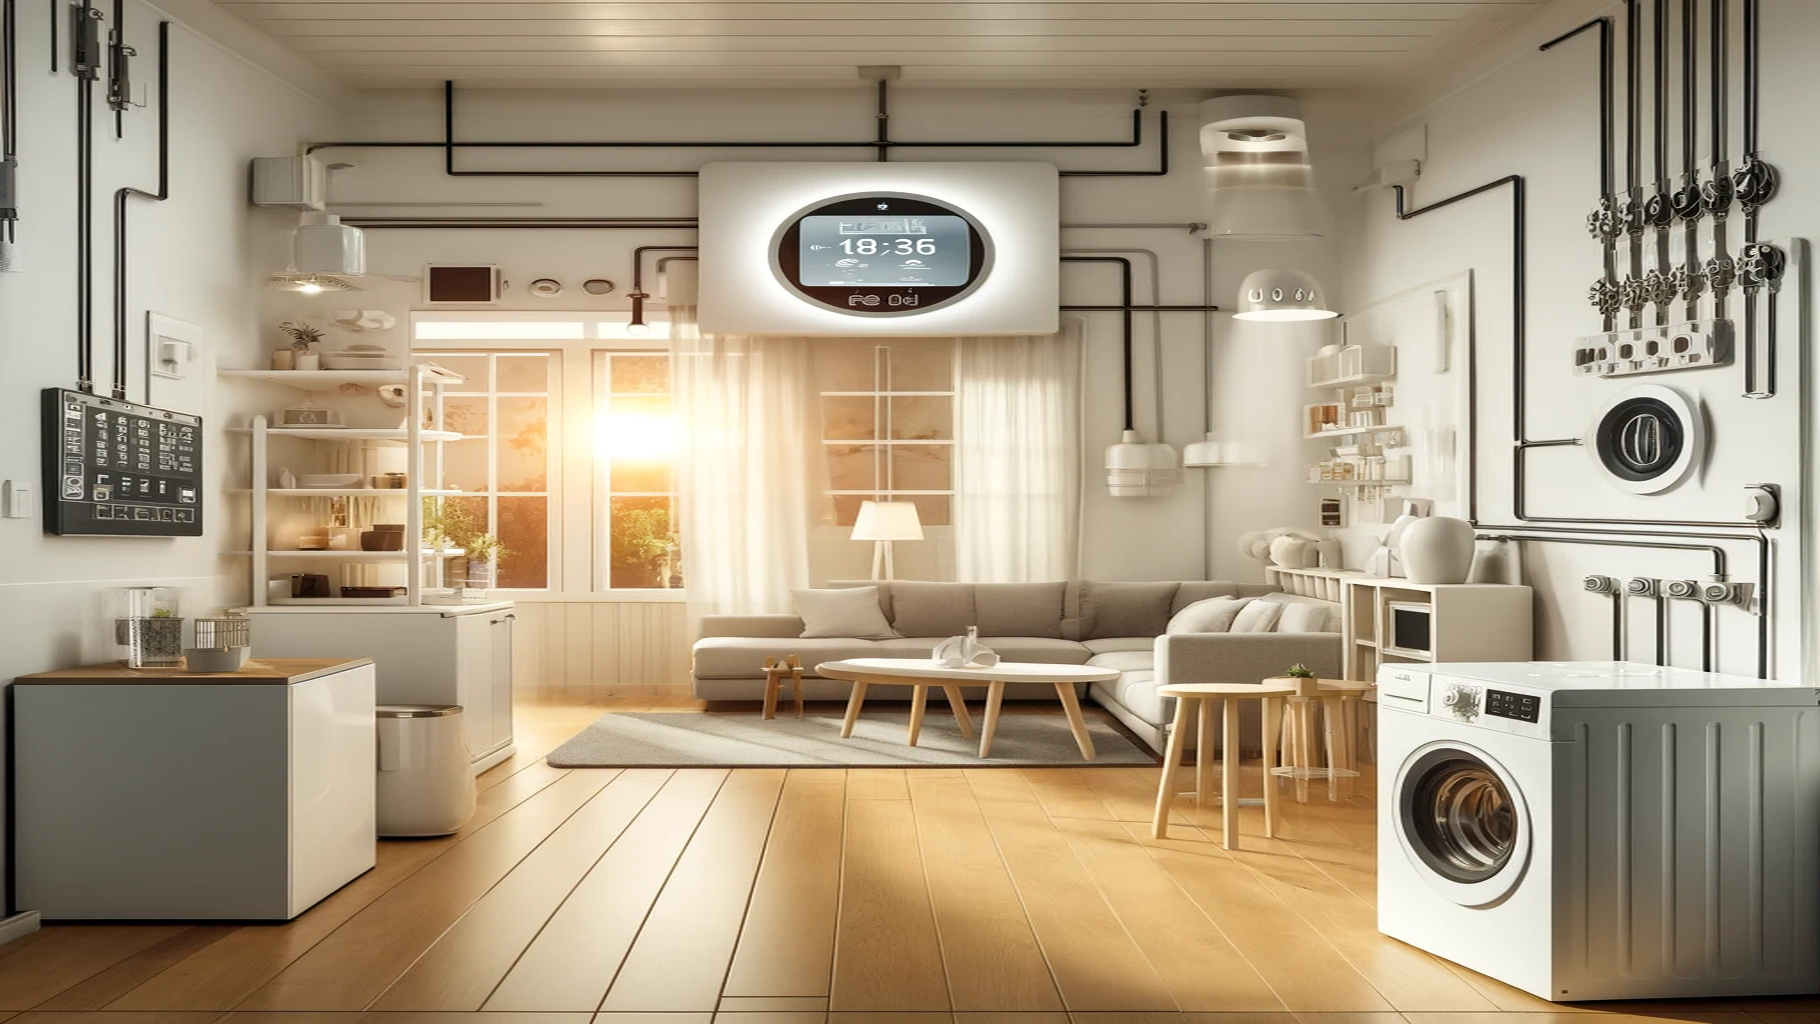

#### Follow detail instructions in the assignment specification and use these heading for implementation and discussion

In [1]:
# seed the random numbers for reproducibility 
# do not remove this line
import random 
random.seed(10)

### 1. Analyse and visualise the data

#### 1.1. Read the dataset

In [2]:
import warnings
warnings.filterwarnings("ignore",category=FutureWarning)

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

orginal_df = pd.read_csv('energydata_complete.csv')
print(orginal_df.shape)
orginal_df.head()

(14941, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,14/02/2016 0:00,50,10,21.790000,39.900000,20.100000,40.79,21.39,40.59,19.2,...,18.0,41.933333,2.90,732.90,98.000000,2.000000,31.0,2.6,48.320978,48.320978
1,14/02/2016 0:10,50,0,21.790000,39.900000,20.033333,40.73,21.39,40.59,19.2,...,18.0,42.133333,2.87,732.95,98.166667,2.166667,28.5,2.6,33.339359,33.339359
2,14/02/2016 0:20,60,10,21.700000,39.933333,19.890000,40.79,21.39,40.53,19.2,...,18.0,42.360000,2.83,733.00,98.333333,2.333333,26.0,2.6,8.168115,8.168115
3,14/02/2016 0:30,40,0,21.633333,39.860000,19.890000,40.79,21.39,40.59,19.2,...,18.0,42.633333,2.80,733.05,98.500000,2.500000,23.5,2.6,16.197509,16.197509
4,14/02/2016 0:40,60,10,21.600000,39.900000,19.790000,40.79,21.39,40.59,19.1,...,18.0,42.860000,2.77,733.10,98.666667,2.666667,21.0,2.6,12.559574,12.559574


In [3]:
#Keep the original df isolated
df = orginal_df.copy()
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.head()

/tmp/ipykernel_21693/3931192104.py:3: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-02-14 00:00:00,50,10,21.790000,39.900000,20.100000,40.79,21.39,40.59,19.2,41.00,...,18.0,41.933333,2.90,732.90,98.000000,2.000000,31.0,2.6,48.320978,48.320978
2016-02-14 00:10:00,50,0,21.790000,39.900000,20.033333,40.73,21.39,40.59,19.2,41.06,...,18.0,42.133333,2.87,732.95,98.166667,2.166667,28.5,2.6,33.339359,33.339359
2016-02-14 00:20:00,60,10,21.700000,39.933333,19.890000,40.79,21.39,40.53,19.2,41.09,...,18.0,42.360000,2.83,733.00,98.333333,2.333333,26.0,2.6,8.168115,8.168115
2016-02-14 00:30:00,40,0,21.633333,39.860000,19.890000,40.79,21.39,40.59,19.2,41.09,...,18.0,42.633333,2.80,733.05,98.500000,2.500000,23.5,2.6,16.197509,16.197509
2016-02-14 00:40:00,60,10,21.600000,39.900000,19.790000,40.79,21.39,40.59,19.1,41.09,...,18.0,42.860000,2.77,733.10,98.666667,2.666667,21.0,2.6,12.559574,12.559574


In [4]:
# date time year-month-day hour:minute:second 
# Appliances, energy use in Wh
# lights, energy use of light fixtures in the house in Wh
# T1, Temperature in kitchen area, in Celsius
# RH_1, Humidity in kitchen area, in %
# T2, Temperature in living room area, in Celsius
# RH_2, Humidity in living room area, in %
# T3, Temperature in laundry room area
# RH_3, Humidity in laundry room area, in %
# T4, Temperature in office room, in Celsius
# RH_4, Humidity in office room, in %
# T5, Temperature in bathroom, in Celsius
# RH_5, Humidity in bathroom, in %
# T6, Temperature outside the building (north side), in Celsius
# RH_6, Humidity outside the building (north side), in %
# T7, Temperature in ironing room , in Celsius
# RH_7, Humidity in ironing room, in %
# T8, Temperature in teenager room 2, in Celsius
# RH_8, Humidity in teenager room 2, in %
# T9, Temperature in parents room, in Celsius
# RH_9, Humidity in parents room, in %
# To_out, Temperature outside (from Chievres weather station), in Celsius
# Press_mg_hg, Pressure (from Chievres weather station), in mm Hg
# RH_out, Humidity outside (from Chievres weather station), in %
# Wind speed (from Chievres weather station), in m/s
# Visibility (from Chievres weather station), in km
# Tdewpoint (from Chievres weather station), Â°C
# rv1, Random variable 1, nondimensional
# rv2, Random variable 2, nondimensional

# !!!rv1 and rv2 are just for testing the robustness of the model, it should not rely on these variables
# the model should be able to predict the energy use without these variables
print(f"Shape of the df: {df.shape}")
print(f"Columns in the df: {df.columns}")

Shape of the df: (14941, 28)
Columns in the df: Index(['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4',
       'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9',
       'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility',
       'Tdewpoint', 'rv1', 'rv2'],
      dtype='object')


#### 1.2. Analyse data characteristics

In [5]:
df.describe()
# lights seems unneccessary

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,...,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000
mean,96.747206,3.235393,22.030776,39.418672,20.519140,39.935868,22.770465,38.046386,21.425985,37.701517,...,20.143157,40.454742,8.182569,755.575393,77.559434,3.671039,37.922696,4.055227,25.047636,25.047636
std,97.297111,7.296554,1.469766,3.880367,2.322643,4.328421,1.897689,2.530175,1.843571,3.701348,...,1.782497,3.566295,5.464633,6.613943,15.720014,2.218070,11.415145,4.220123,14.436670,14.436670
min,10.000000,0.000000,18.600000,27.023333,16.200000,20.463333,19.100000,28.766667,17.290000,27.660000,...,17.260000,29.166667,-4.400000,732.900000,24.000000,0.000000,1.000000,-6.100000,0.005322,0.005322
25%,50.000000,0.000000,21.000000,36.790000,18.890000,37.260000,21.390000,36.363333,20.100000,34.900000,...,18.571429,38.030000,4.230000,751.200000,66.666667,2.000000,29.000000,0.983000,12.593007,12.593007
50%,60.000000,0.000000,21.823333,38.790000,20.000000,39.900000,22.566667,37.760000,21.166667,37.200000,...,20.000000,39.863333,7.630000,755.700000,80.833333,3.166667,40.000000,3.600000,25.120708,25.120708
75%,100.000000,0.000000,22.890000,41.400000,21.830000,42.700000,24.033333,39.260000,22.738571,39.700000,...,20.890000,42.530000,11.400000,760.200000,90.833333,5.000000,40.000000,6.900000,37.454428,37.454428
max,900.000000,50.000000,26.260000,57.496667,29.856667,56.026667,29.236000,47.693333,26.200000,50.760000,...,24.500000,51.536000,26.100000,772.300000,100.000000,13.000000,66.000000,15.500000,49.992758,49.992758


In [6]:
# Analyse data characteristics (dependencies, distributions, etc.) that may affect the prediction task, and visualise them using suitable techniques and charts. Include required charts, diagrams, tables and discussion in Jupyter Notebook.
# checking for data types
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 14941 entries, 2016-02-14 00:00:00 to 2016-05-27 18:00:00
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   14941 non-null  int64  
 1   lights       14941 non-null  int64  
 2   T1           14941 non-null  float64
 3   RH_1         14941 non-null  float64
 4   T2           14941 non-null  float64
 5   RH_2         14941 non-null  float64
 6   T3           14941 non-null  float64
 7   RH_3         14941 non-null  float64
 8   T4           14941 non-null  float64
 9   RH_4         14941 non-null  float64
 10  T5           14941 non-null  float64
 11  RH_5         14941 non-null  float64
 12  T6           14941 non-null  float64
 13  RH_6         14941 non-null  float64
 14  T7           14941 non-null  float64
 15  RH_7         14941 non-null  float64
 16  T8           14941 non-null  float64
 17  RH_8         14941 non-null  float64
 18  T9         

In [7]:
# checking for missing values
df.isnull().sum()

Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

In [8]:
# checking for duplicates
df.duplicated().sum()

0

In [9]:
temperature_columns = [i for i in df.columns if "T" in i]
humidity_columns = [i for i in df.columns if "RH" in i]
other_columns = [i for i in df.columns if ("T" not in i)&("RH" not in i)]

In [10]:
df[temperature_columns].describe()

,T1,T2,T3,T4,T5,T6,T7,T8,T9,T_out,Tdewpoint
count,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000
mean,22.030776,20.519140,22.770465,21.425985,20.023137,8.871416,20.938858,22.670173,20.143157,8.182569,4.055227
std,1.469766,2.322643,1.897689,1.843571,1.779364,6.282378,1.875446,1.554819,1.782497,5.464633,4.220123
min,18.600000,16.200000,19.100000,17.290000,16.921429,-5.712000,17.100000,19.000000,17.260000,-4.400000,-6.100000
25%,21.000000,18.890000,21.390000,20.100000,18.600000,4.156667,19.390000,21.533333,18.571429,4.230000,0.983000
50%,21.823333,20.000000,22.566667,21.166667,19.890000,8.166667,20.890000,22.671429,20.000000,7.630000,3.600000
75%,22.890000,21.830000,24.033333,22.738571,20.890000,12.733333,22.200000,23.733117,20.890000,11.400000,6.900000
max,26.260000,29.856667,29.236000,26.200000,25.795000,28.290000,26.000000,27.230000,24.500000,26.100000,15.500000


In [11]:
df[humidity_columns].describe()

,RH_1,RH_2,RH_3,RH_4,RH_5,RH_6,RH_7,RH_8,RH_9,RH_out
count,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000
mean,39.418672,39.935868,38.046386,37.701517,49.424425,43.167347,34.104729,41.407950,40.454742,77.559434
std,3.880367,4.328421,2.530175,3.701348,8.476811,26.715321,4.652837,4.561967,3.566295,15.720014
min,27.023333,20.463333,28.766667,27.660000,29.815000,1.000000,23.200000,29.600000,29.166667,24.000000
25%,36.790000,37.260000,36.363333,34.900000,44.538571,20.993333,30.671429,38.230000,38.030000,66.666667
50%,38.790000,39.900000,37.760000,37.200000,47.500000,45.766667,33.730000,40.918000,39.863333,80.833333
75%,41.400000,42.700000,39.260000,39.700000,51.590000,62.986111,37.090000,43.966667,42.530000,90.833333
max,57.496667,56.026667,47.693333,50.760000,93.554000,93.500000,48.290000,55.400000,51.536000,100.000000


In [12]:
df[other_columns].describe()


,Appliances,lights,Press_mm_hg,Windspeed,Visibility,rv1,rv2
count,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000
mean,96.747206,3.235393,755.575393,3.671039,37.922696,25.047636,25.047636
std,97.297111,7.296554,6.613943,2.218070,11.415145,14.436670,14.436670
min,10.000000,0.000000,732.900000,0.000000,1.000000,0.005322,0.005322
25%,50.000000,0.000000,751.200000,2.000000,29.000000,12.593007,12.593007
50%,60.000000,0.000000,755.700000,3.166667,40.000000,25.120708,25.120708
75%,100.000000,0.000000,760.200000,5.000000,40.000000,37.454428,37.454428
max,900.000000,50.000000,772.300000,13.000000,66.000000,49.992758,49.992758


In [13]:
#creating new features
df['hour'] = df.index.hour
df['day'] = df.index.day
df['month'] = df.index.month
df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,hour,day,month
date,,,,,,,,,,,,,,,,,,,,,
2016-02-14 00:00:00,50,10,21.790000,39.900000,20.100000,40.79,21.39,40.59,19.2,41.00,...,732.90,98.000000,2.000000,31.0,2.6,48.320978,48.320978,0,14,2
2016-02-14 00:10:00,50,0,21.790000,39.900000,20.033333,40.73,21.39,40.59,19.2,41.06,...,732.95,98.166667,2.166667,28.5,2.6,33.339359,33.339359,0,14,2
2016-02-14 00:20:00,60,10,21.700000,39.933333,19.890000,40.79,21.39,40.53,19.2,41.09,...,733.00,98.333333,2.333333,26.0,2.6,8.168115,8.168115,0,14,2
2016-02-14 00:30:00,40,0,21.633333,39.860000,19.890000,40.79,21.39,40.59,19.2,41.09,...,733.05,98.500000,2.500000,23.5,2.6,16.197509,16.197509,0,14,2
2016-02-14 00:40:00,60,10,21.600000,39.900000,19.790000,40.79,21.39,40.59,19.1,41.09,...,733.10,98.666667,2.666667,21.0,2.6,12.559574,12.559574,0,14,2


Text(0, 0.5, 'Energy Usage (Wh)')

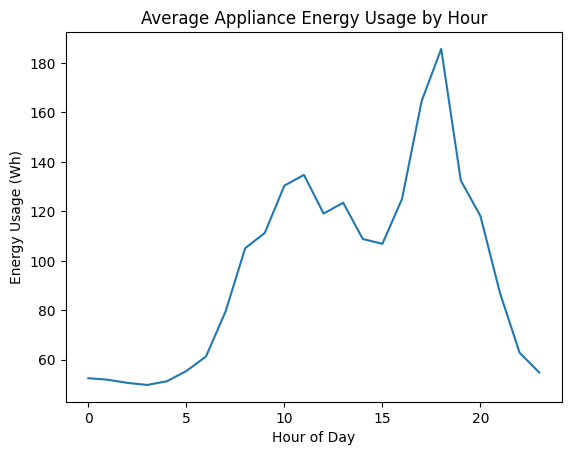

In [14]:
daily_energy = df.groupby('hour')['Appliances'].mean()
sns.lineplot(x=daily_energy.index, y=daily_energy.values)
plt.title('Average Appliance Energy Usage by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Energy Usage (Wh)')

/tmp/ipykernel_21693/1496576862.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Appliances'], hist=True, color = 'blue',hist_kws={'edgecolor':'black'},ax=axes[0])
/tmp/ipykernel_21693/1496576862.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['log_appliances'], hist=True, color = 

Text(0.5, 0, 'Appliances log(wH)')

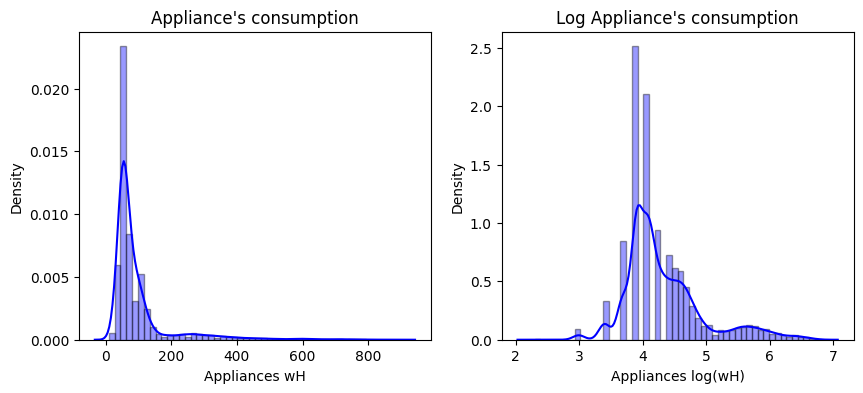

In [15]:
f, axes = plt.subplots(1, 2,figsize=(10,4))

sns.distplot(df['Appliances'], hist=True, color = 'blue',hist_kws={'edgecolor':'black'},ax=axes[0])
axes[0].set_title("Appliance's consumption")
axes[0].set_xlabel('Appliances wH')


df['log_appliances'] = np.log(df['Appliances'])
sns.distplot(df['log_appliances'], hist=True, color = 'blue',hist_kws={'edgecolor':'black'},ax=axes[1])
axes[1].set_title("Log Appliance's consumption")
axes[1].set_xlabel('Appliances log(wH)')

In [16]:
# around 10 and dinner time 
# late night and morning are the lowest 
# => Useful

Text(0.5, 1.0, 'Average Indoor Temperature vs Energy Usage')

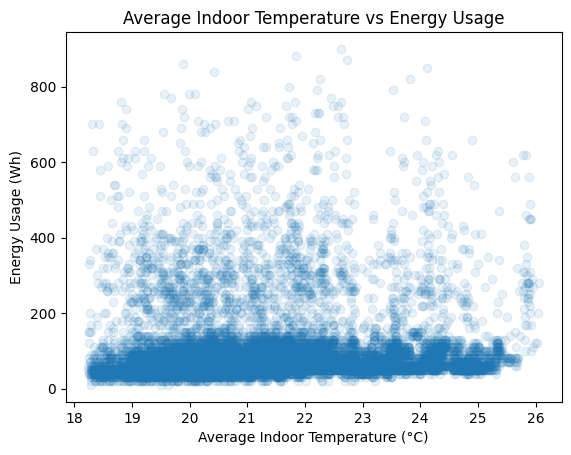

In [17]:
# avarage inside temp impact on energy usage
avg_indoor_temps = df[['T1', 'T2', 'T3', 'T4', 'T5', 'T7', 'T8', 'T9']].mean(axis=1)
plt.scatter(avg_indoor_temps, df['Appliances'], alpha=0.1)
plt.xlabel('Average Indoor Temperature (°C)')
plt.ylabel('Energy Usage (Wh)')
plt.title('Average Indoor Temperature vs Energy Usage')

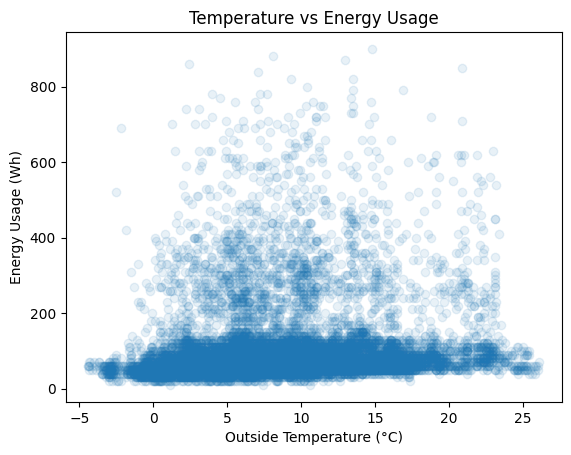

In [18]:

# Outside temp impact on energy usage
plt.scatter(df['T_out'], df['Appliances'], alpha=0.1)
plt.xlabel('Outside Temperature (°C)')
plt.ylabel('Energy Usage (Wh)')
plt.title('Temperature vs Energy Usage')
plt.show()

Text(0.5, 1.0, 'Indoor vs Outdoor Temperature')

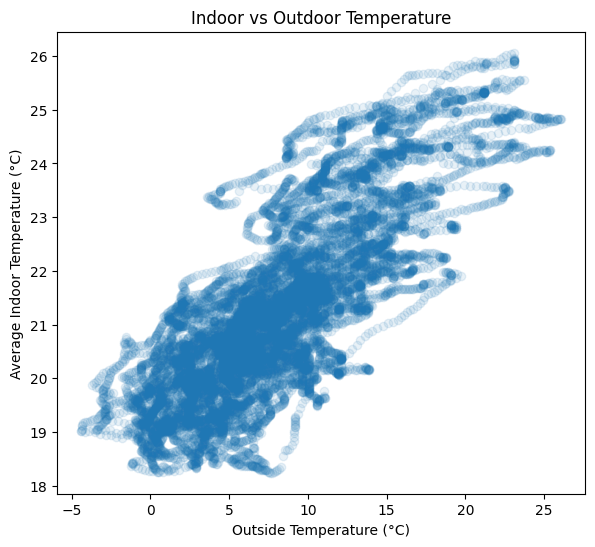

In [19]:
# indoor vs outdoor
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.scatter(df['T_out'], avg_indoor_temps, alpha=0.1)
plt.xlabel('Outside Temperature (°C)')
plt.ylabel('Average Indoor Temperature (°C)')
plt.title('Indoor vs Outdoor Temperature')

<Figure size 1200x600 with 0 Axes>

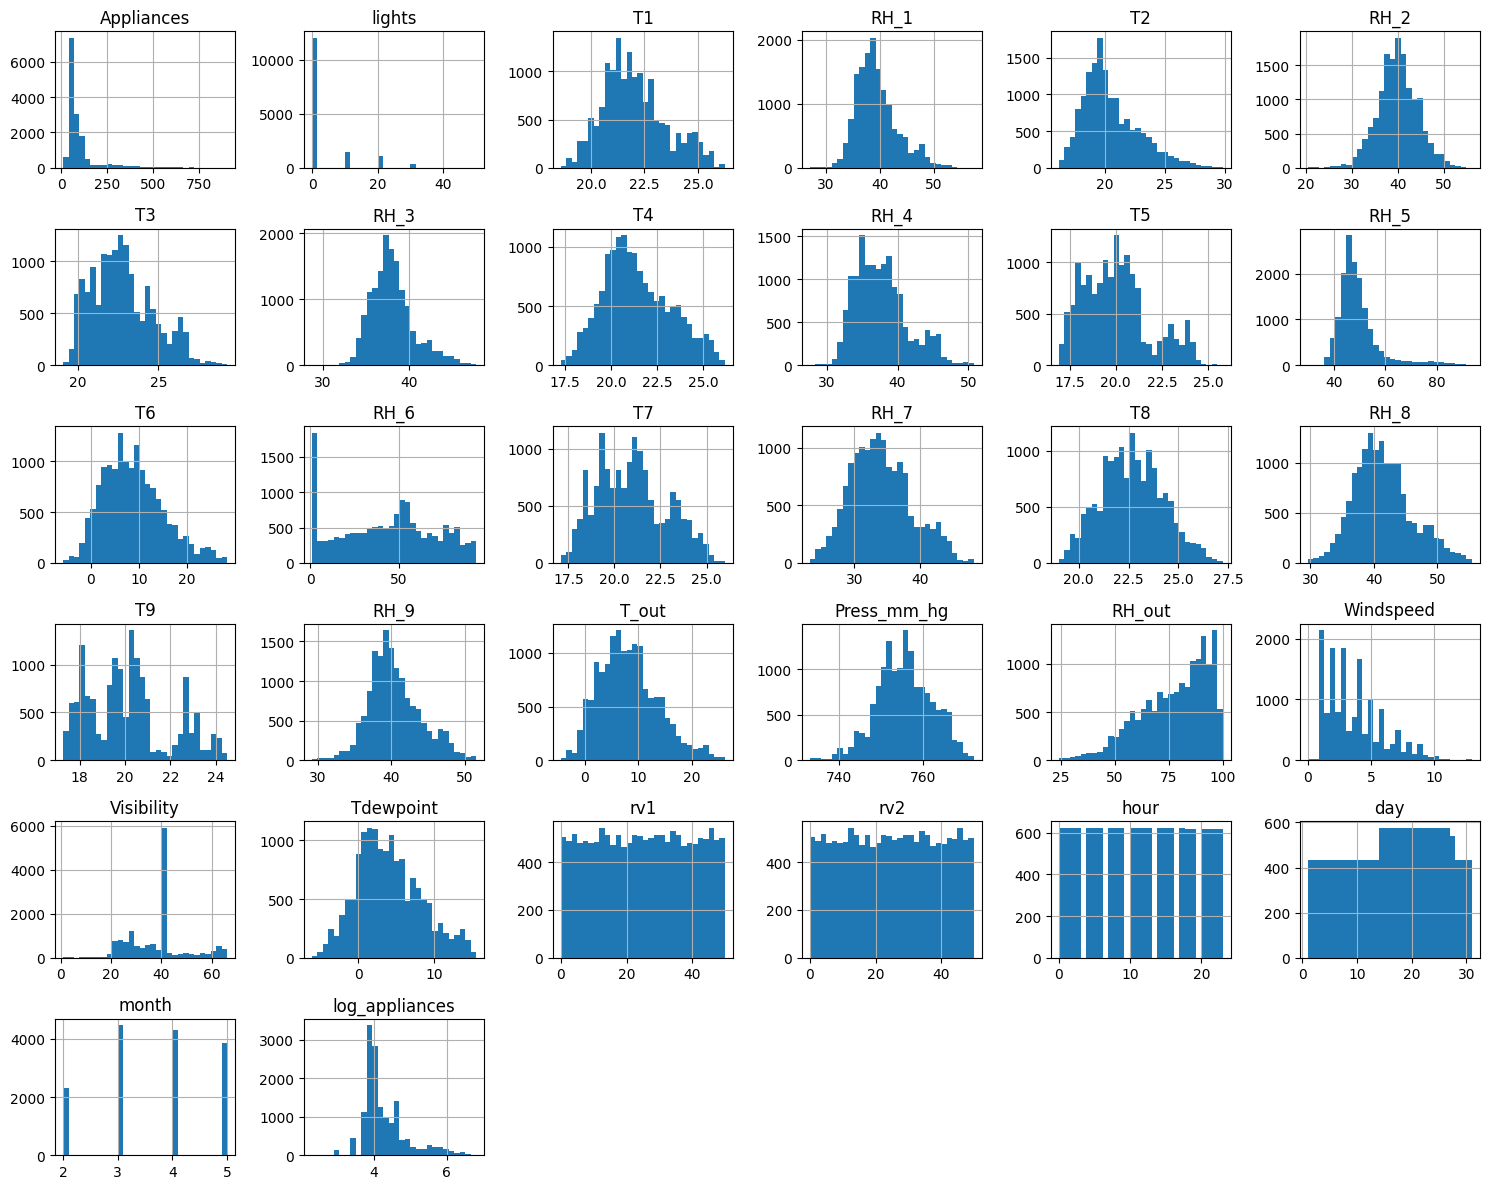

In [20]:
plt.figure(figsize=(12, 6))
df.hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

In [21]:
# some of them are normally distributed, some are not
# some implications for the model:
#1. statistical models assume normal distribution like linear regression might not work well
#2. can use log to normalize the data
#3. Outliers
#4. Need data understanding to decide which model to use
#5. Need to handle skewed data

In [22]:
#Friday, Saturday Sunday and Monday have higher energy usage, alot of outliers above 200

In [23]:
#does not show nay correlation => Temp might be useless

In [25]:
numeric_data = df.select_dtypes(include=[np.number])
df_hour = numeric_data.resample('1H').mean()

In [26]:
df.drop(['Appliances', 'rv1', 'rv2'], axis=1, inplace=True)

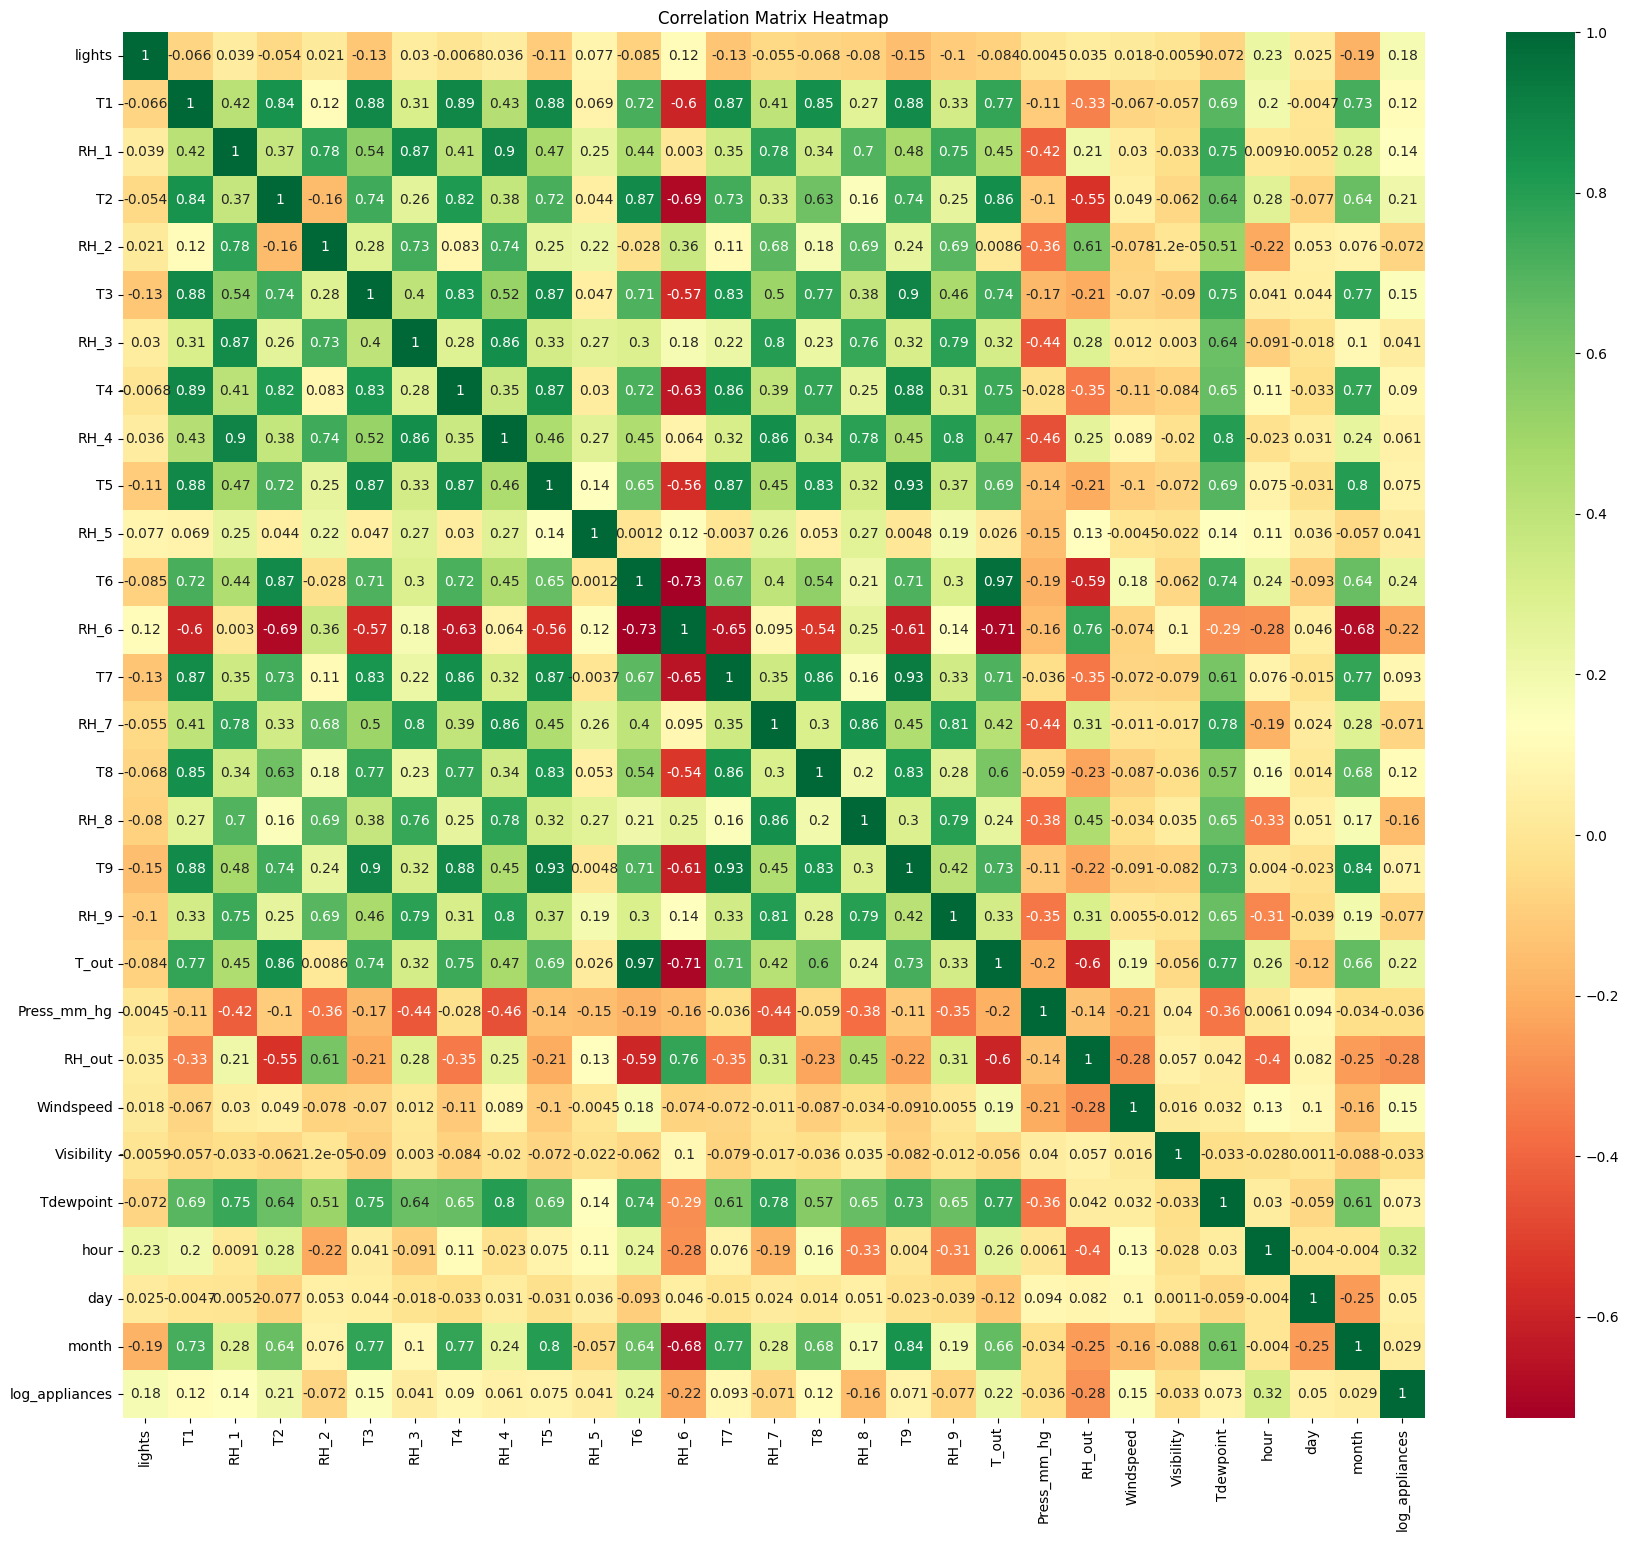

In [27]:
# Correlation Heatmap visualization code
correlation_matrix = df.corr()
plt.figure(figsize=(21, 18))
sns.heatmap(correlation_matrix, annot=True, cmap="RdYlGn")
plt.title("Correlation Matrix Heatmap")
plt.show()

In [28]:
# appliance are not strongly correlated with any of the features, indicating non-linear relationship -> need to use non-linear models

In [29]:
# indoor and outdoor doesnt matter that much 

In [30]:
# indoor_temps

In [31]:
# 3. Discuss the results of your analysis and visualisation. Make sure your charts are of good quality and useful, there is no point to make a chart or a table, if it is not referred to in your discussion. 


### 2. Pre-process the data

In [32]:
df['avg_indoor_temp']=df[['T1', 'T2', 'T3', 'T4', 'T5', 'T7', 'T8', 'T9']].mean(axis=1)
df['temp_diff']=abs(df['avg_indoor_temp']-df['T_out'])

df['avg_indoor_hum']=df[['RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_7', 'RH_8', 'RH_9']].mean(axis=1)
#create a column of difference between outside and inside building humidity
df['hum_diff']=abs(df['RH_out']-df['avg_indoor_hum'])

print(df.shape)

df.head(2)


(14941, 33)


,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,Visibility,Tdewpoint,hour,day,month,log_appliances,avg_indoor_temp,temp_diff,avg_indoor_hum,hum_diff
date,,,,,,,,,,,,,,,,,,,,,
2016-02-14 00:00:00,10,21.79,39.9,20.100000,40.79,21.39,40.59,19.2,41.00,18.2,...,31.0,2.6,0,14,2,3.912023,19.946250,17.046250,42.250417,55.749583
2016-02-14 00:10:00,0,21.79,39.9,20.033333,40.73,21.39,40.59,19.2,41.06,18.2,...,28.5,2.6,0,14,2,3.912023,19.937917,17.067917,42.311736,55.854931


In [33]:
df.columns

Index(['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5',
       'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out',
       'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour',
       'day', 'month', 'log_appliances', 'avg_indoor_temp', 'temp_diff',
       'avg_indoor_hum', 'hum_diff'],
      dtype='object')

In [34]:
chosen_columns = ['hour', 'temp_diff', 'hum_diff', 'lights', 'T6', 'RH_6', 'Press_mm_hg', 'Windspeed', 'Visibility', 'Tdewpoint', 'log_appliances']

In [35]:
len(chosen_columns)

11

In [40]:
df = df[chosen_columns]
numeric_data = df.select_dtypes(include=[np.number])
df_hour = numeric_data.resample('1H').mean()

df_hour.head()

,hour,temp_diff,hum_diff,lights,T6,RH_6,Press_mm_hg,Windspeed,Visibility,Tdewpoint,log_appliances
date,,,,,,,,,,,
2016-02-14 00:00:00,0.0,17.080475,56.001794,6.666667,3.432778,92.137500,733.025000,2.416667,24.750000,2.600000,3.965993
2016-02-14 01:00:00,1.0,17.116944,56.155446,0.000000,3.304444,92.366667,733.241667,2.583333,17.250000,2.600000,3.972797
2016-02-14 02:00:00,2.0,17.057593,55.422731,0.000000,3.200000,92.444444,733.466667,2.000000,26.916667,2.516667,3.991685
2016-02-14 03:00:00,3.0,16.976690,54.240764,0.000000,3.215000,92.450833,733.908333,2.000000,37.583333,2.358333,3.795718
2016-02-14 04:00:00,4.0,16.988947,52.724010,0.000000,3.172222,92.443889,734.283333,2.000000,44.916667,2.091667,4.059262


In [44]:
#Spliting
train_dev_size = int(len(df_hour) * 0.8)

dev_size = int(train_dev_size*0.9)

df_train_dev = df_hour.iloc[:train_dev_size] # first 75% of the data
df_test = df_hour.iloc[train_dev_size:] # remaining 25% of the data

df_train = df_train_dev.iloc[:dev_size] 
df_dev = df_train_dev.iloc[dev_size:]

X_train = df_train.drop(columns=['log_appliances'])
y_train = df_train['log_appliances']

X_dev = df_dev.drop(columns=['log_appliances'])
y_dev = df_dev['log_appliances']

X_test = df_test.drop(columns=['log_appliances'])
y_test = df_test['log_appliances']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_dev shape: {X_dev.shape}")
print(f"y_dev shape: {y_dev.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1792, 10)
y_train shape: (1792,)
X_dev shape: (200, 10)
y_dev shape: (200,)
X_test shape: (499, 10)
y_test shape: (499,)


In [45]:
X_train

,hour,temp_diff,hum_diff,lights,T6,RH_6,Press_mm_hg,Windspeed,Visibility,Tdewpoint
date,,,,,,,,,,
2016-02-14 00:00:00,0.0,17.080475,56.001794,6.666667,3.432778,92.137500,733.025000,2.416667,24.750000,2.600000
2016-02-14 01:00:00,1.0,17.116944,56.155446,0.000000,3.304444,92.366667,733.241667,2.583333,17.250000,2.600000
2016-02-14 02:00:00,2.0,17.057593,55.422731,0.000000,3.200000,92.444444,733.466667,2.000000,26.916667,2.516667
2016-02-14 03:00:00,3.0,16.976690,54.240764,0.000000,3.215000,92.450833,733.908333,2.000000,37.583333,2.358333
2016-02-14 04:00:00,4.0,16.988947,52.724010,0.000000,3.172222,92.443889,734.283333,2.000000,44.916667,2.091667
...,...,...,...,...,...,...,...,...,...,...
2016-04-28 11:00:00,11.0,13.173976,33.763819,5.000000,8.880000,27.408889,756.258333,3.416667,40.000000,1.791667
2016-04-28 12:00:00,12.0,13.723542,34.592917,0.000000,8.227778,45.787778,756.325000,4.000000,40.000000,1.250000
2016-04-28 13:00:00,13.0,14.540556,39.838490,0.000000,9.452778,37.813333,756.437500,3.791667,40.000000,1.441667


In [46]:
from sklearn.preprocessing import StandardScaler

# Normalizing of X matrices for each model to mean = 0 and standard deviation = 1

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
X_train

array([[-1.65783582,  0.76783876,  1.24398549, ..., -0.62652701,
        -1.15815609, -0.02203182],
       [-1.51322709,  0.77807158,  1.25602066, ..., -0.55536415,
        -1.79975282, -0.02203182],
       [-1.36861836,  0.76141849,  1.19862885, ..., -0.80443416,
        -0.97280592, -0.04722281],
       ...,
       [ 0.2220777 ,  0.05518203, -0.0220491 , ..., -0.03943344,
         0.14642393, -0.37218667],
       [ 0.36668643, -0.48314661, -0.22386669, ..., -0.25292201,
         0.14642393,  0.02079288],
       [ 0.51129516, -0.66874997, -0.31845827, ...,  0.15626442,
        -0.28130723,  0.13667146]])

### 4. Test the final model and analyse results

#### Linear regression

In [48]:
from sklearn import linear_model

lin_model = linear_model.LinearRegression()
lin_model.fit(X_train,y_train)

LinearRegression()

In [49]:
from sklearn import svm

svr_model = svm.SVR(gamma='scale')
svr_model.fit(X_train,y_train)

SVR()

In [50]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100,random_state=1)            
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=1)

In [51]:
import xgboost as xgb
from xgboost import plot_importance
import lightgbm as lgb
from catboost import CatBoostRegressor as cbr

model_lgb = lgb.LGBMRegressor(num_leaves=41, n_estimators=200)
model_lgb.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1870
[LightGBM] [Info] Number of data points in the train set: 1792, number of used features: 10
[LightGBM] [Info] Start training from score 4.309624


LGBMRegressor(n_estimators=200, num_leaves=41)

In [52]:
model_xgb = xgb.XGBRegressor(objective='reg:squarederror')
model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [53]:
model_cbr = cbr(random_seed=242, verbose=0, early_stopping_rounds=10)
model_cbr.fit(X_train, y_train)

In [54]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn import metrics

# Function to evaluate the models
def evaluate(model, test_features, test_labels):
    predictions = model.predict(test_features)
    errors = abs(predictions - test_labels)
    mape = 100 * np.mean(errors / test_labels)
    r_score = 100*r2_score(test_labels,predictions)
    accuracy = 100 - mape
    print(model,'\n')
    print('Average Error       : {:0.4f} degrees'.format(np.mean(errors)))
    print('Variance score R^2  : {:0.2f}%' .format(r_score))
    print('Accuracy            : {:0.2f}%\n'.format(accuracy))

In [55]:
evaluate(lin_model, X_test, y_test)
evaluate(svr_model, X_test, y_test)
evaluate(rf_model, X_test, y_test)
evaluate(model_lgb, X_test, y_test)
evaluate(model_xgb, X_test, y_test)
evaluate(model_cbr, X_test, y_test)

LinearRegression() 

Average Error       : 0.3790 degrees
Variance score R^2  : 7.22%
Accuracy            : 91.23%

SVR() 

Average Error       : 0.3154 degrees
Variance score R^2  : 11.63%
Accuracy            : 93.18%

RandomForestRegressor(random_state=1) 

Average Error       : 0.2962 degrees
Variance score R^2  : 26.18%
Accuracy            : 93.44%

LGBMRegressor(n_estimators=200, num_leaves=41) 

Average Error       : 0.3235 degrees
Variance score R^2  : 13.32%
Accuracy            : 92.87%

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta

/home/james/MyFolder/code/GIT/mbd/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [56]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Create a base model
rf = RandomForestRegressor(random_state=1)

# Instantiate the grid search model
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

Fitting 3 folds for each of 648 candidates, totalling 1944 fits
[CV] END bootstrap=True, max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.0s
[CV] END bootstrap=True, max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators

/home/james/MyFolder/code/GIT/mbd/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
300 fits failed with the following error:
Traceback (most recent call last):
  File "/home/james/MyFolder/code/GIT/mbd/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/james/MyFolder/code/GIT/mbd/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/home/james/MyFolder/code/GIT/mbd/.venv/lib/python3.12/site-packages/sklearn/base.py", line 436,

Best parameters found:  {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
Best score:  -0.21047702763448076


In [60]:
rf_model = RandomForestRegressor(n_estimators=200,random_state=1)            
rf_model.fit(X_train, y_train)

evaluate(rf_model, X_test, y_test)

RandomForestRegressor(n_estimators=200, random_state=1) 

Average Error       : 0.2993 degrees
Variance score R^2  : 24.11%
Accuracy            : 93.38%



### 5. Reflection

Follow the guidelines in the assignment specification


### 6. References

### 7. Appendix

Use this section as needed for longer analysis and expanded charting